<b>Cash Flow Matching Problem</b>

In [ ]:
# Input data
Bonds = {'Bond 1', 'Bond 2', 'Bond 3', 'Bond 4', 'Bond 5', 'Bond 6' }
Years = range(1,4)       # {1,2,3}  This needs to be an ordered set!

Return = {
    ('Bond 1', 1): 10,	('Bond 1', 2): 10,	('Bond 1', 3): 110,
    ('Bond 2', 1): 7,	('Bond 2', 2): 7,	('Bond 2', 3): 107,
    ('Bond 3', 1): 8,	('Bond 3', 2): 8,	('Bond 3', 3): 108,
    ('Bond 4', 1): 6,	('Bond 4', 2): 106,	
    ('Bond 5', 1): 7,	('Bond 5', 2): 107,	
    ('Bond 6', 1): 105
}

Price = {'Bond 1' : 109, 'Bond 2' : 94.8, 'Bond 3' : 99.5, 'Bond 4' : 93.1, 'Bond 5' : 97.2, 'Bond 6' : 92.9 } # price in $/bond

Liability = { 1: 100, 2: 800, 3: 1200 }  # in k$

## fdsfds


Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 23.4.0 23E214)

CPU model: Apple M3 Max
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 3 rows, 9 columns and 19 nonzeros
Model fingerprint: 0x27bad303
Coefficient statistics:
  Matrix range     [1e+00, 1e+02]
  Objective range  [9e+01, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 1e+03]
Presolve removed 0 rows and 1 columns
Presolve time: 0.00s
Presolved: 3 rows, 8 columns, 18 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   2.876250e+02   0.000000e+00      0s
       5    1.6806364e+03   0.000000e+00   0.000000e+00      0s

Solved in 5 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.680636450e+03

Optimal Investment Strategy:
  Bond 2: $11.2150k
  Bond 4: $6.6322k

Surplus at End of Each Year:
  Year 1: $18.30k
  Year 2: $0.00k
  Year 3: $0.00k

Cash Flow Validation:
Ye

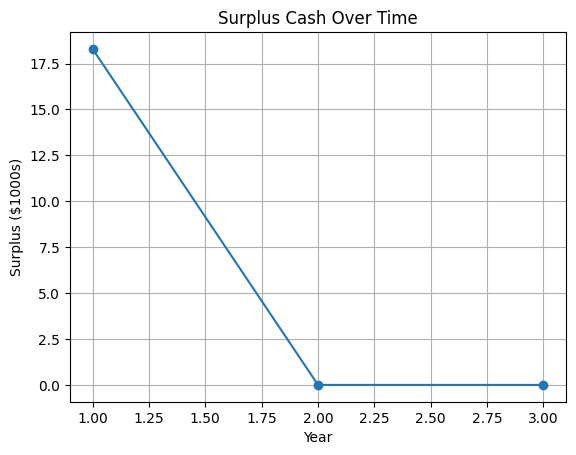

In [2]:
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

Bonds = ['Bond 1', 'Bond 2', 'Bond 3', 'Bond 4', 'Bond 5', 'Bond 6']
Years = [1, 2, 3]
alpha = 1.01  # Interest rate on surplus

Return = {
    'Bond 1': {1: 10, 2: 10, 3: 110},
    'Bond 2': {1: 7,  2: 7,  3: 107},
    'Bond 3': {1: 8,  2: 8,  3: 108},
    'Bond 4': {1: 6,  2: 106},
    'Bond 5': {1: 7,  2: 107},
    'Bond 6': {1: 105}
}

Price = {
    'Bond 1': 109, 'Bond 2': 94.8, 'Bond 3': 99.5,
    'Bond 4': 93.1, 'Bond 5': 97.2, 'Bond 6': 92.9
}

Liability = {1: 100, 2: 800, 3: 1200}

# Optional penalty on surplus
penalty = {t: 0 for t in Years}  # Set small values like 0.001 if needed

# Build model

model = gp.Model("CashFlowMatching")

x = model.addVars(Bonds, name="x", lb=0)
b = model.addVars(Years, name="b", lb=0)

# Objective: Minimize cost (optionally include penalty on surplus)
model.setObjective(
    gp.quicksum(Price[i] * x[i] for i in Bonds) + gp.quicksum(penalty[t] * b[t] for t in Years),
    GRB.MINIMIZE
)

# Constraints
model.addConstr(
    gp.quicksum(Return[i].get(1, 0) * x[i] for i in Bonds) - Liability[1] == b[1],
    name="cash_balance_1"
)

for t in Years[1:]:
    inflow = gp.quicksum(Return[i].get(t, 0) * x[i] for i in Bonds)
    model.addConstr(
        alpha * b[t - 1] + inflow - Liability[t] == b[t],
        name=f"cash_balance_{t}"
    )

model.optimize()

# Results
if model.status == GRB.OPTIMAL:
 if model.status == GRB.OPTIMAL:
    print("\nOptimal Investment Strategy:")
    for i in Bonds:
        if x[i].X > 1e-6:
            print(f"  {i}: ${x[i].X:.4f}k")

    print("\nSurplus at End of Each Year:")
    for t in Years:
        print(f"  Year {t}: ${b[t].X:.2f}k")

    print("\nCash Flow Validation:")
    for t in Years:
        payoff = sum(Return[i].get(t, 0) * x[i].X for i in Bonds)
        if t == 1:
            print(f"Year {t}: payoff = {payoff:.2f}, liability = {Liability[t]}, cash balance = {b[t].X:.2f}")
        else:
            interest = alpha * b[t-1].X
            total_inflow = payoff + interest
            print(f"Year {t}: payoff = {payoff:.2f}, interest = {interest:.2f}, total inflow = {total_inflow:.2f}, "
                  f"liability = {Liability[t]}, cash balance = {b[t].X:.2f}")

    # Plot Surplus Over Time
    surplus = [b[t].X for t in Years]
    plt.plot(Years, surplus, marker='o')
    plt.title("Surplus Cash Over Time")
    plt.xlabel("Year")
    plt.ylabel("Surplus ($1000s)")
    plt.grid(True)
    plt.show()
else:
    print("\nNo optimal solution found.")
